In [1]:
import numpy as np
import pandas as pd
import sklearn.impute , sklearn.preprocessing
import seaborn 
import matplotlib.pyplot as plt

In [2]:
data_train = pd.read_excel('../data/processed/disaster_prediction_train.xlsx')
data_train

,disno.,historic,disaster_group,disaster_subgroup,disaster_type,disaster_subtype,external_ids,event_name,country,region,origin,associated_types,magnitude,magnitude_scale,latitude,longitude,start_year,start_month,admin_units,gadm_admin_units
0,1977-0118-USA,Yes,Natural,Hydrological,Flood,Flash flood,NaN,NaN,United States of America,Americas,NaN,NaN,NaN,Km2,NaN,NaN,1977,9.0,NaN,NaN
1,2021-9546-ETH,No,Natural,Climatological,Drought,Drought,GLIDE:DR-2021-000121,NaN,Ethiopia,Africa,NaN,Food shortage,NaN,Km2,NaN,NaN,2021,5.0,"[{""adm1_code"":1228,""adm1_name"":""Afar""},{""adm1_...","[{""gid_1"":""ETH.11_1"",""migration_date"":""2025-12..."
2,2014-0555-CHN,No,Natural,Meteorological,Storm,Lightning/Thunderstorms,NaN,NaN,China,Asia,NaN,NaN,NaN,Kph,NaN,NaN,2014,8.0,"[{""adm2_code"":13065,""adm2_name"":""Zunyi""}]","[{""gid_2"":""CHN.8.9_1"",""migration_date"":""2025-1..."
3,2002-0197-VNM,No,Natural,Climatological,Wildfire,Forest fire,NaN,NaN,Viet Nam,Asia,NaN,NaN,55.0,Km2,NaN,NaN,2002,3.0,"[{""adm1_code"":3339,""adm1_name"":""Ca Mau""},{""adm...","[{""gid_1"":""VNM.13_1"",""migration_date"":""2025-12..."
4,2001-0042-SLV,No,Natural,Geophysical,Earthquake,Ground movement,USGS:usp000a9jv,NaN,El Salvador,Americas,NaN,"Slide (land, mud, snow, rock)",6.6,Moment Magnitude,13.671,-88.938,2001,2.0,"[{""adm1_code"":1187,""adm1_name"":""Cuscatlan""},{""...","[{""gid_1"":""SLV.10_1"",""migration_date"":""2025-12..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12424,1963-0001-LBY,Yes,Natural,Geophysical,Earthquake,Ground movement,NaN,NaN,Libya,Africa,NaN,NaN,5.4,Moment Magnitude,32.600,21.000,1963,2.0,NaN,NaN
12425,2019-0182-ZAF,No,Natural,Hydrological,Flood,Flood (General),NaN,NaN,South Africa,Africa,Heavy rains,NaN,NaN,Km2,NaN,NaN,2019,5.0,"[{""adm1_code"":77310,""adm1_name"":""Eastern Cape""}]","[{""gid_1"":""ZAF.1_1"",""migration_date"":""2025-12-..."
12426,1985-0141-IND,Yes,Natural,Meteorological,Extreme temperature,Cold wave,NaN,NaN,India,Asia,NaN,NaN,NaN,°C,NaN,NaN,1985,12.0,NaN,NaN
12427,2003-0176-OMN,No,Natural,Meteorological,Storm,Storm (General),NaN,NaN,Oman,Asia,NaN,NaN,NaN,Kph,NaN,NaN,2003,4.0,"[{""adm1_code"":2270,""adm1_name"":""Muscat""},{""adm...","[{""gid_1"":""OMN.11_1"",""migration_date"":""2025-12..."


In [3]:
data_test = pd.read_excel('../data/processed/disaster_prediction_test.xlsx')
data_test

,disno.,historic,disaster_group,disaster_subgroup,disaster_type,disaster_subtype,external_ids,event_name,country,region,origin,associated_types,magnitude,magnitude_scale,latitude,longitude,start_year,start_month,admin_units,gadm_admin_units
0,2003-0774-MYS,No,Natural,Hydrological,Flood,Riverine flood,NaN,NaN,Malaysia,Asia,Continuous rains,NaN,NaN,Km2,NaN,NaN,2003,10.0,"[{""adm1_code"":1892,""adm1_name"":""Kedah""},{""adm1...","[{""gid_1"":""MYS.2_1"",""migration_date"":""2025-12-..."
1,2015-0199-PER,No,Natural,Hydrological,Flood,Riverine flood,GLIDE:FL-2015-000011,NaN,Peru,Americas,NaN,NaN,NaN,Km2,NaN,NaN,2015,4.0,"[{""adm2_code"":24143,""adm2_name"":""Loreto""},{""ad...","[{""gid_2"":""PER.17.1_1"",""migration_date"":""2025-..."
2,2024-0617-GIN,No,Natural,Hydrological,Flood,Flood (General),GLIDE:FL-2024-000148,NaN,Guinea,Africa,Heavy rains,NaN,NaN,Km2,NaN,NaN,2024,7.0,NaN,NaN
3,2016-0187-NPL,No,Natural,Climatological,Wildfire,Forest fire,NaN,NaN,Nepal,Asia,Combination of well above normal temperature a...,NaN,NaN,Km2,NaN,NaN,2016,2.0,"[{""adm2_code"":22352,""adm2_name"":""Janakpur""},{""...","[{""gid_2"":""NPL.1.2_1"",""migration_date"":""2025-1..."
4,2009-0204-IND,No,Natural,Meteorological,Storm,Tropical cyclone,GLIDE:TC-2009-000105,"Cyclone ""Aila""",India,Asia,NaN,"Flood|Slide (land, mud, snow, rock)",110.0,Kph,NaN,NaN,2009,5.0,"[{""adm2_code"":17948,""adm2_name"":""Darjiling""},{...","[{""gid_2"":""IND.36.11_1"",""migration_date"":""2025..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5322,1940-0033-TUR,Yes,Natural,Geophysical,Earthquake,Ground movement,NaN,NaN,Türkiye,Asia,NaN,NaN,6.0,Moment Magnitude,41.7,43.8,1940,5.0,NaN,NaN
5323,2014-0057-IDN,No,Natural,Hydrological,Flood,Riverine flood,NaN,NaN,Indonesia,Asia,Heavy rains,"Slide (land, mud, snow, rock)",NaN,Km2,NaN,NaN,2014,1.0,"[{""adm1_code"":1520,""adm1_name"":""Jawa Tengah""},...","[{""gid_1"":""IDN.10_1"",""migration_date"":""2025-12..."
5324,1980-9114-CIV,Yes,Natural,Climatological,Drought,Drought,NaN,NaN,Côte d’Ivoire,Africa,NaN,Crop failure|Food shortage,NaN,Km2,NaN,NaN,1983,NaN,NaN,NaN
5325,2017-0472-IRN,No,Natural,Hydrological,Flood,Flash flood,NaN,NaN,Iran (Islamic Republic of),Asia,Extreme rainfall,NaN,NaN,Km2,NaN,NaN,2017,8.0,"[{""adm1_code"":1547,""adm1_name"":""Khorasan""},{""a...","[{""gid_1"":""IRN.12_1"",""migration_date"":""2025-12..."


In [4]:
data_train.isnull().mean()*100

disno.                0.000000
historic              0.000000
disaster_group        0.000000
disaster_subgroup     0.000000
disaster_type         0.000000
disaster_subtype      0.000000
external_ids         74.173304
event_name           75.693942
country               0.000000
region                0.000000
origin               73.658380
associated_types     76.007724
magnitude            70.094135
magnitude_scale      11.754767
latitude             83.932738
longitude            83.932738
start_year            0.000000
start_month           2.124065
admin_units          52.948749
gadm_admin_units     56.102663
dtype: float64

In [5]:
data_train.info(0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12429 entries, 0 to 12428
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   disno.             12429 non-null  object 
 1   historic           12429 non-null  object 
 2   disaster_group     12429 non-null  object 
 3   disaster_subgroup  12429 non-null  object 
 4   disaster_type      12429 non-null  object 
 5   disaster_subtype   12429 non-null  object 
 6   external_ids       3210 non-null   object 
 7   event_name         3021 non-null   object 
 8   country            12429 non-null  object 
 9   region             12429 non-null  object 
 10  origin             3274 non-null   object 
 11  associated_types   2982 non-null   object 
 12  magnitude          3717 non-null   float64
 13  magnitude_scale    10968 non-null  object 
 14  latitude           1997 non-null   float64
 15  longitude          1997 non-null   float64
 16  start_year         124

In [6]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5327 entries, 0 to 5326
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   disno.             5327 non-null   object 
 1   historic           5327 non-null   object 
 2   disaster_group     5327 non-null   object 
 3   disaster_subgroup  5327 non-null   object 
 4   disaster_type      5327 non-null   object 
 5   disaster_subtype   5327 non-null   object 
 6   external_ids       1384 non-null   object 
 7   event_name         1298 non-null   object 
 8   country            5327 non-null   object 
 9   region             5327 non-null   object 
 10  origin             1443 non-null   object 
 11  associated_types   1286 non-null   object 
 12  magnitude          1571 non-null   float64
 13  magnitude_scale    4685 non-null   object 
 14  latitude           836 non-null    float64
 15  longitude          836 non-null    float64
 16  start_year         5327 

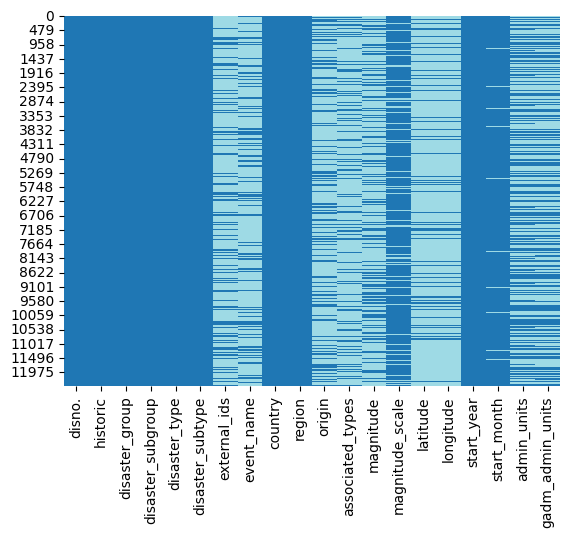

In [7]:
seaborn.heatmap(data_train.isnull(),cbar=False,cmap='tab20')
plt.show()

In [8]:
data_train.isnull().sum()

disno.                   0
historic                 0
disaster_group           0
disaster_subgroup        0
disaster_type            0
disaster_subtype         0
external_ids          9219
event_name            9408
country                  0
region                   0
origin                9155
associated_types      9447
magnitude             8712
magnitude_scale       1461
latitude             10432
longitude            10432
start_year               0
start_month            264
admin_units           6581
gadm_admin_units      6973
dtype: int64

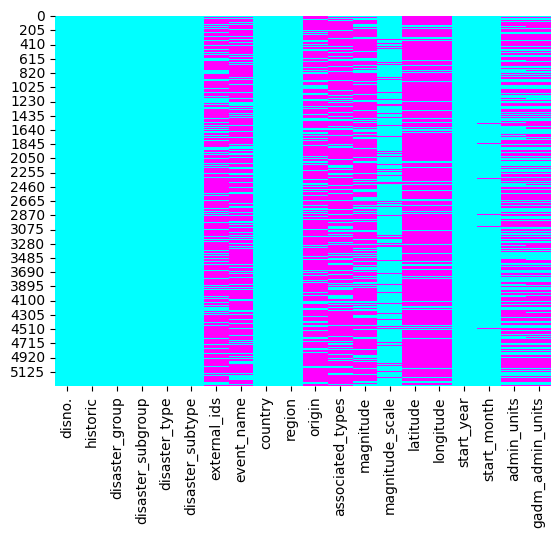

In [9]:
seaborn.heatmap(data_test.isnull(),cbar=False,cmap='cool')
plt.show()

In [10]:
data_test.isnull().sum()

disno.                  0
historic                0
disaster_group          0
disaster_subgroup       0
disaster_type           0
disaster_subtype        0
external_ids         3943
event_name           4029
country                 0
region                  0
origin               3884
associated_types     4041
magnitude            3756
magnitude_scale       642
latitude             4491
longitude            4491
start_year              0
start_month           108
admin_units          2803
gadm_admin_units     2972
dtype: int64

In [11]:
data_train['disaster_type'].value_counts()

disaster_type
Flood                  4328
Storm                  3537
Earthquake             1156
Epidemic               1135
Landslide               643
Drought                 562
Extreme temperature     511
Wildfire                360
Volcanic activity       197
Name: count, dtype: int64

In [12]:
data_test['disaster_type'].value_counts()

disaster_type
Flood                  1855
Storm                  1516
Earthquake              495
Epidemic                487
Landslide               275
Drought                 241
Extreme temperature     219
Wildfire                154
Volcanic activity        85
Name: count, dtype: int64

In [13]:
data_train['disaster_type'].value_counts(normalize=True) * 100

disaster_type
Flood                  34.821788
Storm                  28.457639
Earthquake              9.300829
Epidemic                9.131869
Landslide               5.173385
Drought                 4.521683
Extreme temperature     4.111352
Wildfire                2.896452
Volcanic activity       1.585003
Name: proportion, dtype: float64

In [14]:
data_test['disaster_type'].value_counts(normalize=True) * 100

disaster_type
Flood                  34.822602
Storm                  28.458795
Earthquake              9.292285
Epidemic                9.142106
Landslide               5.162380
Drought                 4.524122
Extreme temperature     4.111132
Wildfire                2.890933
Volcanic activity       1.595645
Name: proportion, dtype: float64

In [15]:
# handling missing values
from sklearn.impute import SimpleImputer

In [16]:
# separate it first
X_train = data_train.drop("disaster_type", axis=1)
y_train = data_train["disaster_type"]

X_test = data_test.drop("disaster_type", axis=1)
y_test = data_test["disaster_type"]

In [17]:

categorical_features_train = data_train.select_dtypes(include=['object', 'category']).columns
categorical_features_train

Index(['disno.', 'historic', 'disaster_group', 'disaster_subgroup',
       'disaster_type', 'disaster_subtype', 'external_ids', 'event_name',
       'country', 'region', 'origin', 'associated_types', 'magnitude_scale',
       'admin_units', 'gadm_admin_units'],
      dtype='object')

In [18]:
categorical_features_test = data_test.select_dtypes(include=['object', 'category']).columns
categorical_features_test

Index(['disno.', 'historic', 'disaster_group', 'disaster_subgroup',
       'disaster_type', 'disaster_subtype', 'external_ids', 'event_name',
       'country', 'region', 'origin', 'associated_types', 'magnitude_scale',
       'admin_units', 'gadm_admin_units'],
      dtype='object')

In [19]:
categorical_features_data_train = data_train[categorical_features_train]
categorical_features_data_train

,disno.,historic,disaster_group,disaster_subgroup,disaster_type,disaster_subtype,external_ids,event_name,country,region,origin,associated_types,magnitude_scale,admin_units,gadm_admin_units
0,1977-0118-USA,Yes,Natural,Hydrological,Flood,Flash flood,NaN,NaN,United States of America,Americas,NaN,NaN,Km2,NaN,NaN
1,2021-9546-ETH,No,Natural,Climatological,Drought,Drought,GLIDE:DR-2021-000121,NaN,Ethiopia,Africa,NaN,Food shortage,Km2,"[{""adm1_code"":1228,""adm1_name"":""Afar""},{""adm1_...","[{""gid_1"":""ETH.11_1"",""migration_date"":""2025-12..."
2,2014-0555-CHN,No,Natural,Meteorological,Storm,Lightning/Thunderstorms,NaN,NaN,China,Asia,NaN,NaN,Kph,"[{""adm2_code"":13065,""adm2_name"":""Zunyi""}]","[{""gid_2"":""CHN.8.9_1"",""migration_date"":""2025-1..."
3,2002-0197-VNM,No,Natural,Climatological,Wildfire,Forest fire,NaN,NaN,Viet Nam,Asia,NaN,NaN,Km2,"[{""adm1_code"":3339,""adm1_name"":""Ca Mau""},{""adm...","[{""gid_1"":""VNM.13_1"",""migration_date"":""2025-12..."
4,2001-0042-SLV,No,Natural,Geophysical,Earthquake,Ground movement,USGS:usp000a9jv,NaN,El Salvador,Americas,NaN,"Slide (land, mud, snow, rock)",Moment Magnitude,"[{""adm1_code"":1187,""adm1_name"":""Cuscatlan""},{""...","[{""gid_1"":""SLV.10_1"",""migration_date"":""2025-12..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12424,1963-0001-LBY,Yes,Natural,Geophysical,Earthquake,Ground movement,NaN,NaN,Libya,Africa,NaN,NaN,Moment Magnitude,NaN,NaN
12425,2019-0182-ZAF,No,Natural,Hydrological,Flood,Flood (General),NaN,NaN,South Africa,Africa,Heavy rains,NaN,Km2,"[{""adm1_code"":77310,""adm1_name"":""Eastern Cape""}]","[{""gid_1"":""ZAF.1_1"",""migration_date"":""2025-12-..."
12426,1985-0141-IND,Yes,Natural,Meteorological,Extreme temperature,Cold wave,NaN,NaN,India,Asia,NaN,NaN,°C,NaN,NaN
12427,2003-0176-OMN,No,Natural,Meteorological,Storm,Storm (General),NaN,NaN,Oman,Asia,NaN,NaN,Kph,"[{""adm1_code"":2270,""adm1_name"":""Muscat""},{""adm...","[{""gid_1"":""OMN.11_1"",""migration_date"":""2025-12..."


In [20]:
categorical_features_data_test = data_test[categorical_features_test]
categorical_features_data_test

,disno.,historic,disaster_group,disaster_subgroup,disaster_type,disaster_subtype,external_ids,event_name,country,region,origin,associated_types,magnitude_scale,admin_units,gadm_admin_units
0,2003-0774-MYS,No,Natural,Hydrological,Flood,Riverine flood,NaN,NaN,Malaysia,Asia,Continuous rains,NaN,Km2,"[{""adm1_code"":1892,""adm1_name"":""Kedah""},{""adm1...","[{""gid_1"":""MYS.2_1"",""migration_date"":""2025-12-..."
1,2015-0199-PER,No,Natural,Hydrological,Flood,Riverine flood,GLIDE:FL-2015-000011,NaN,Peru,Americas,NaN,NaN,Km2,"[{""adm2_code"":24143,""adm2_name"":""Loreto""},{""ad...","[{""gid_2"":""PER.17.1_1"",""migration_date"":""2025-..."
2,2024-0617-GIN,No,Natural,Hydrological,Flood,Flood (General),GLIDE:FL-2024-000148,NaN,Guinea,Africa,Heavy rains,NaN,Km2,NaN,NaN
3,2016-0187-NPL,No,Natural,Climatological,Wildfire,Forest fire,NaN,NaN,Nepal,Asia,Combination of well above normal temperature a...,NaN,Km2,"[{""adm2_code"":22352,""adm2_name"":""Janakpur""},{""...","[{""gid_2"":""NPL.1.2_1"",""migration_date"":""2025-1..."
4,2009-0204-IND,No,Natural,Meteorological,Storm,Tropical cyclone,GLIDE:TC-2009-000105,"Cyclone ""Aila""",India,Asia,NaN,"Flood|Slide (land, mud, snow, rock)",Kph,"[{""adm2_code"":17948,""adm2_name"":""Darjiling""},{...","[{""gid_2"":""IND.36.11_1"",""migration_date"":""2025..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5322,1940-0033-TUR,Yes,Natural,Geophysical,Earthquake,Ground movement,NaN,NaN,Türkiye,Asia,NaN,NaN,Moment Magnitude,NaN,NaN
5323,2014-0057-IDN,No,Natural,Hydrological,Flood,Riverine flood,NaN,NaN,Indonesia,Asia,Heavy rains,"Slide (land, mud, snow, rock)",Km2,"[{""adm1_code"":1520,""adm1_name"":""Jawa Tengah""},...","[{""gid_1"":""IDN.10_1"",""migration_date"":""2025-12..."
5324,1980-9114-CIV,Yes,Natural,Climatological,Drought,Drought,NaN,NaN,Côte d’Ivoire,Africa,NaN,Crop failure|Food shortage,Km2,NaN,NaN
5325,2017-0472-IRN,No,Natural,Hydrological,Flood,Flash flood,NaN,NaN,Iran (Islamic Republic of),Asia,Extreme rainfall,NaN,Km2,"[{""adm1_code"":1547,""adm1_name"":""Khorasan""},{""a...","[{""gid_1"":""IRN.12_1"",""migration_date"":""2025-12..."


In [21]:
data_train.isnull().mean()*100

disno.                0.000000
historic              0.000000
disaster_group        0.000000
disaster_subgroup     0.000000
disaster_type         0.000000
disaster_subtype      0.000000
external_ids         74.173304
event_name           75.693942
country               0.000000
region                0.000000
origin               73.658380
associated_types     76.007724
magnitude            70.094135
magnitude_scale      11.754767
latitude             83.932738
longitude            83.932738
start_year            0.000000
start_month           2.124065
admin_units          52.948749
gadm_admin_units     56.102663
dtype: float64

In [22]:
categorical_impute= SimpleImputer(strategy='most_frequent')
categorical_impute

SimpleImputer(strategy='most_frequent')

In [23]:
categorical_impute.fit(categorical_features_data_train)

SimpleImputer(strategy='most_frequent')

In [24]:
categorical_features_data_train = pd.DataFrame(
    data = categorical_impute.transform(categorical_features_data_train),
    columns = categorical_impute.get_feature_names_out(),
    index = categorical_features_data_train.index
)
categorical_features_data_train

,disno.,historic,disaster_group,disaster_subgroup,disaster_type,disaster_subtype,external_ids,event_name,country,region,origin,associated_types,magnitude_scale,admin_units,gadm_admin_units
0,1977-0118-USA,Yes,Natural,Hydrological,Flood,Flash flood,GLIDE:HT-2022-000399,Cholera,United States of America,Americas,Heavy rains,"Slide (land, mud, snow, rock)",Km2,"[{""adm1_code"":925,""adm1_name"":""Taiwan Sheng""}]","[{""gid_1"":""TWN.2_1"",""migration_date"":""2025-12-..."
1,2021-9546-ETH,No,Natural,Climatological,Drought,Drought,GLIDE:DR-2021-000121,Cholera,Ethiopia,Africa,Heavy rains,Food shortage,Km2,"[{""adm1_code"":1228,""adm1_name"":""Afar""},{""adm1_...","[{""gid_1"":""ETH.11_1"",""migration_date"":""2025-12..."
2,2014-0555-CHN,No,Natural,Meteorological,Storm,Lightning/Thunderstorms,GLIDE:HT-2022-000399,Cholera,China,Asia,Heavy rains,"Slide (land, mud, snow, rock)",Kph,"[{""adm2_code"":13065,""adm2_name"":""Zunyi""}]","[{""gid_2"":""CHN.8.9_1"",""migration_date"":""2025-1..."
3,2002-0197-VNM,No,Natural,Climatological,Wildfire,Forest fire,GLIDE:HT-2022-000399,Cholera,Viet Nam,Asia,Heavy rains,"Slide (land, mud, snow, rock)",Km2,"[{""adm1_code"":3339,""adm1_name"":""Ca Mau""},{""adm...","[{""gid_1"":""VNM.13_1"",""migration_date"":""2025-12..."
4,2001-0042-SLV,No,Natural,Geophysical,Earthquake,Ground movement,USGS:usp000a9jv,Cholera,El Salvador,Americas,Heavy rains,"Slide (land, mud, snow, rock)",Moment Magnitude,"[{""adm1_code"":1187,""adm1_name"":""Cuscatlan""},{""...","[{""gid_1"":""SLV.10_1"",""migration_date"":""2025-12..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12424,1963-0001-LBY,Yes,Natural,Geophysical,Earthquake,Ground movement,GLIDE:HT-2022-000399,Cholera,Libya,Africa,Heavy rains,"Slide (land, mud, snow, rock)",Moment Magnitude,"[{""adm1_code"":925,""adm1_name"":""Taiwan Sheng""}]","[{""gid_1"":""TWN.2_1"",""migration_date"":""2025-12-..."
12425,2019-0182-ZAF,No,Natural,Hydrological,Flood,Flood (General),GLIDE:HT-2022-000399,Cholera,South Africa,Africa,Heavy rains,"Slide (land, mud, snow, rock)",Km2,"[{""adm1_code"":77310,""adm1_name"":""Eastern Cape""}]","[{""gid_1"":""ZAF.1_1"",""migration_date"":""2025-12-..."
12426,1985-0141-IND,Yes,Natural,Meteorological,Extreme temperature,Cold wave,GLIDE:HT-2022-000399,Cholera,India,Asia,Heavy rains,"Slide (land, mud, snow, rock)",°C,"[{""adm1_code"":925,""adm1_name"":""Taiwan Sheng""}]","[{""gid_1"":""TWN.2_1"",""migration_date"":""2025-12-..."
12427,2003-0176-OMN,No,Natural,Meteorological,Storm,Storm (General),GLIDE:HT-2022-000399,Cholera,Oman,Asia,Heavy rains,"Slide (land, mud, snow, rock)",Kph,"[{""adm1_code"":2270,""adm1_name"":""Muscat""},{""adm...","[{""gid_1"":""OMN.11_1"",""migration_date"":""2025-12..."


In [25]:
categorical_features_data_test = pd.DataFrame(
    data = categorical_impute.transform(categorical_features_data_test),
    columns = categorical_impute.get_feature_names_out(),
    index = categorical_features_data_test.index
)
categorical_features_data_test

,disno.,historic,disaster_group,disaster_subgroup,disaster_type,disaster_subtype,external_ids,event_name,country,region,origin,associated_types,magnitude_scale,admin_units,gadm_admin_units
0,2003-0774-MYS,No,Natural,Hydrological,Flood,Riverine flood,GLIDE:HT-2022-000399,Cholera,Malaysia,Asia,Continuous rains,"Slide (land, mud, snow, rock)",Km2,"[{""adm1_code"":1892,""adm1_name"":""Kedah""},{""adm1...","[{""gid_1"":""MYS.2_1"",""migration_date"":""2025-12-..."
1,2015-0199-PER,No,Natural,Hydrological,Flood,Riverine flood,GLIDE:FL-2015-000011,Cholera,Peru,Americas,Heavy rains,"Slide (land, mud, snow, rock)",Km2,"[{""adm2_code"":24143,""adm2_name"":""Loreto""},{""ad...","[{""gid_2"":""PER.17.1_1"",""migration_date"":""2025-..."
2,2024-0617-GIN,No,Natural,Hydrological,Flood,Flood (General),GLIDE:FL-2024-000148,Cholera,Guinea,Africa,Heavy rains,"Slide (land, mud, snow, rock)",Km2,"[{""adm1_code"":925,""adm1_name"":""Taiwan Sheng""}]","[{""gid_1"":""TWN.2_1"",""migration_date"":""2025-12-..."
3,2016-0187-NPL,No,Natural,Climatological,Wildfire,Forest fire,GLIDE:HT-2022-000399,Cholera,Nepal,Asia,Combination of well above normal temperature a...,"Slide (land, mud, snow, rock)",Km2,"[{""adm2_code"":22352,""adm2_name"":""Janakpur""},{""...","[{""gid_2"":""NPL.1.2_1"",""migration_date"":""2025-1..."
4,2009-0204-IND,No,Natural,Meteorological,Storm,Tropical cyclone,GLIDE:TC-2009-000105,"Cyclone ""Aila""",India,Asia,Heavy rains,"Flood|Slide (land, mud, snow, rock)",Kph,"[{""adm2_code"":17948,""adm2_name"":""Darjiling""},{...","[{""gid_2"":""IND.36.11_1"",""migration_date"":""2025..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5322,1940-0033-TUR,Yes,Natural,Geophysical,Earthquake,Ground movement,GLIDE:HT-2022-000399,Cholera,Türkiye,Asia,Heavy rains,"Slide (land, mud, snow, rock)",Moment Magnitude,"[{""adm1_code"":925,""adm1_name"":""Taiwan Sheng""}]","[{""gid_1"":""TWN.2_1"",""migration_date"":""2025-12-..."
5323,2014-0057-IDN,No,Natural,Hydrological,Flood,Riverine flood,GLIDE:HT-2022-000399,Cholera,Indonesia,Asia,Heavy rains,"Slide (land, mud, snow, rock)",Km2,"[{""adm1_code"":1520,""adm1_name"":""Jawa Tengah""},...","[{""gid_1"":""IDN.10_1"",""migration_date"":""2025-12..."
5324,1980-9114-CIV,Yes,Natural,Climatological,Drought,Drought,GLIDE:HT-2022-000399,Cholera,Côte d’Ivoire,Africa,Heavy rains,Crop failure|Food shortage,Km2,"[{""adm1_code"":925,""adm1_name"":""Taiwan Sheng""}]","[{""gid_1"":""TWN.2_1"",""migration_date"":""2025-12-..."
5325,2017-0472-IRN,No,Natural,Hydrological,Flood,Flash flood,GLIDE:HT-2022-000399,Cholera,Iran (Islamic Republic of),Asia,Extreme rainfall,"Slide (land, mud, snow, rock)",Km2,"[{""adm1_code"":1547,""adm1_name"":""Khorasan""},{""a...","[{""gid_1"":""IRN.12_1"",""migration_date"":""2025-12..."


In [26]:
categorical_features_data_train.isnull().sum()

disno.               0
historic             0
disaster_group       0
disaster_subgroup    0
disaster_type        0
disaster_subtype     0
external_ids         0
event_name           0
country              0
region               0
origin               0
associated_types     0
magnitude_scale      0
admin_units          0
gadm_admin_units     0
dtype: int64

In [27]:

categorical_features_data_test.isnull().sum()

disno.               0
historic             0
disaster_group       0
disaster_subgroup    0
disaster_type        0
disaster_subtype     0
external_ids         0
event_name           0
country              0
region               0
origin               0
associated_types     0
magnitude_scale      0
admin_units          0
gadm_admin_units     0
dtype: int64

In [28]:
numerical_features = [
    'magnitude',
    'latitude',
    'longitude',
    'start_year',
    'start_month',
]

In [29]:
numerical_features_data_train = data_train[numerical_features]
numerical_features_data_train

,magnitude,latitude,longitude,start_year,start_month
0,NaN,NaN,NaN,1977,9.0
1,NaN,NaN,NaN,2021,5.0
2,NaN,NaN,NaN,2014,8.0
3,55.0,NaN,NaN,2002,3.0
4,6.6,13.671,-88.938,2001,2.0
...,...,...,...,...,...
12424,5.4,32.600,21.000,1963,2.0
12425,NaN,NaN,NaN,2019,5.0
12426,NaN,NaN,NaN,1985,12.0
12427,NaN,NaN,NaN,2003,4.0


In [30]:

numerical_features_data_test = data_test[numerical_features]
numerical_features_data_test

,magnitude,latitude,longitude,start_year,start_month
0,NaN,NaN,NaN,2003,10.0
1,NaN,NaN,NaN,2015,4.0
2,NaN,NaN,NaN,2024,7.0
3,NaN,NaN,NaN,2016,2.0
4,110.0,NaN,NaN,2009,5.0
...,...,...,...,...,...
5322,6.0,41.7,43.8,1940,5.0
5323,NaN,NaN,NaN,2014,1.0
5324,NaN,NaN,NaN,1983,NaN
5325,NaN,NaN,NaN,2017,8.0


In [31]:
# add missing indicators
from sklearn.impute import MissingIndicator

indicator = MissingIndicator(features='missing-only')

missing_flags = indicator.fit_transform(numerical_features_data_train[['magnitude','latitude','longitude']])

In [32]:
from sklearn.impute import MissingIndicator

indicator = MissingIndicator(features='missing-only')

missing_flags = indicator.fit_transform(numerical_features_data_test[['magnitude','latitude','longitude']])

In [33]:
# impute values
from sklearn.impute import KNNImputer

In [34]:
imputer = KNNImputer(n_neighbors=5)

num_cols = ['magnitude','latitude','longitude','start_year','start_month']
numerical_features_data_train[num_cols] = imputer.fit_transform(numerical_features_data_train[num_cols])

/Users/yazu/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yazu/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yazu/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/var/folders/b6/77jq3l_n51s4g5kpd815pg140000gn/T/ipykernel_10142/3726702947.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  numerical_features_data_train[num_cols] = imputer.fit_transform(numerical_features_data_train[num_cols])


In [35]:
imputer = KNNImputer(n_neighbors=5)

num_cols = ['magnitude','latitude','longitude','start_year','start_month']
numerical_features_data_test[num_cols] = imputer.fit_transform(numerical_features_data_test[num_cols])

/Users/yazu/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yazu/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yazu/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/var/folders/b6/77jq3l_n51s4g5kpd815pg140000gn/T/ipykernel_10142/2127200959.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  numerical_features_data_test[num_cols] = imputer.fit_transform(numerical_features_data_test[num_cols])


In [36]:
numerical_features_data_train.isna().sum(axis='index')

magnitude      0
latitude       0
longitude      0
start_year     0
start_month    0
dtype: int64

In [37]:
categorical_features_data_train.isna().sum(axis='index')

disno.               0
historic             0
disaster_group       0
disaster_subgroup    0
disaster_type        0
disaster_subtype     0
external_ids         0
event_name           0
country              0
region               0
origin               0
associated_types     0
magnitude_scale      0
admin_units          0
gadm_admin_units     0
dtype: int64

In [38]:
train_processed = (
    categorical_features_data_train
    .join(numerical_features_data_train)
)

train_processed['disaster_type'] = y_train

In [39]:
train_processed.head()

,disno.,historic,disaster_group,disaster_subgroup,disaster_type,disaster_subtype,external_ids,event_name,country,region,origin,associated_types,magnitude_scale,admin_units,gadm_admin_units,magnitude,latitude,longitude,start_year,start_month
0,1977-0118-USA,Yes,Natural,Hydrological,Flood,Flash flood,GLIDE:HT-2022-000399,Cholera,United States of America,Americas,Heavy rains,"Slide (land, mud, snow, rock)",Km2,"[{""adm1_code"":925,""adm1_name"":""Taiwan Sheng""}]","[{""gid_1"":""TWN.2_1"",""migration_date"":""2025-12-...",146.860,10.74520,96.1320,1977.0,9.0
1,2021-9546-ETH,No,Natural,Climatological,Drought,Drought,GLIDE:DR-2021-000121,Cholera,Ethiopia,Africa,Heavy rains,Food shortage,Km2,"[{""adm1_code"":1228,""adm1_name"":""Afar""},{""adm1_...","[{""gid_1"":""ETH.11_1"",""migration_date"":""2025-12...",107.900,21.82460,73.3240,2021.0,5.0
2,2014-0555-CHN,No,Natural,Meteorological,Storm,Lightning/Thunderstorms,GLIDE:HT-2022-000399,Cholera,China,Asia,Heavy rains,"Slide (land, mud, snow, rock)",Kph,"[{""adm2_code"":13065,""adm2_name"":""Zunyi""}]","[{""gid_2"":""CHN.8.9_1"",""migration_date"":""2025-1...",4627.802,8.54302,19.8346,2014.0,8.0
3,2002-0197-VNM,No,Natural,Climatological,Wildfire,Forest fire,GLIDE:HT-2022-000399,Cholera,Viet Nam,Asia,Heavy rains,"Slide (land, mud, snow, rock)",Km2,"[{""adm1_code"":3339,""adm1_name"":""Ca Mau""},{""adm...","[{""gid_1"":""VNM.13_1"",""migration_date"":""2025-12...",55.000,11.00280,-30.5654,2002.0,3.0
4,2001-0042-SLV,No,Natural,Geophysical,Earthquake,Ground movement,USGS:usp000a9jv,Cholera,El Salvador,Americas,Heavy rains,"Slide (land, mud, snow, rock)",Moment Magnitude,"[{""adm1_code"":1187,""adm1_name"":""Cuscatlan""},{""...","[{""gid_1"":""SLV.10_1"",""migration_date"":""2025-12...",6.600,13.67100,-88.9380,2001.0,2.0
